<a href="https://colab.research.google.com/github/rtajeong/M3_2026/blob/main/lab43_ridge_lasso(M2_gg31).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 규제화 (Regularization) (2026.6.26)
- L1
- L2

- Ridge(릿지) 회귀와 Lasso(라쏘) 회귀의 규제(Regularization) 메커니즘을 시각적으로 명확하게 비교할 수 있는 파이썬 실습 예제 코드
- 다중공선성(Multicollinearity) 문제를 인위적으로 생성하여, 두 모델이 쓸모없는 다수의 노이즈 피처(Overfitting 유발 인자)를 어떻게 제어하는지 한눈에 확인할 수 있다.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler

In [58]:
# 1. 인위적인 합성 데이터 생성 (피처는 10개지만, 실제 유의미한 피처는 2개뿐인 상황)
np.random.seed(42)
n_samples = 150

# 진짜 원인 변수 2개
X1 = np.random.randn(n_samples)
X2 = np.random.randn(n_samples)

# 강한 다중공선성을 유발하는 노이즈 변수들 생성 (X1, X2와 거의 유사한 무의미한 변수들)
noise_features = [X1 + np.random.randn(n_samples) * 0.05 for _ in range(4)] + \
                 [X2 + np.random.randn(n_samples) * 0.05 for _ in range(4)]

X = np.column_stack([X1, X2] + noise_features)

# 실제 데이터의 규칙: Y = 4*X1 - 3*X2 + 약간의 오차
y = 7 * X1 - 8 * X2 + np.random.randn(n_samples) * 0.5


In [59]:
X.shape, y.shape

((150, 10), (150,))

In [60]:
# 2. 데이터 분할 및 스케일링 (규제 모델은 스케일링이 필수적임)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [76]:
# 3. 모델 정의 및 학습 (규제 강도 alpha를 동일하게 1.0으로 설정)
lr = LinearRegression()
ridge = Ridge(alpha=0.5)
lasso = Lasso(alpha=0.5, max_iter=10000)

lr.fit(X_train_scaled, y_train)
ridge.fit(X_train_scaled, y_train)
lasso.fit(X_train_scaled, y_train)

lr.score(X_test_scaled, y_test), ridge.score(X_test_scaled, y_test), lasso.score(X_test_scaled, y_test)

(0.9970743066730442, 0.9973877235069436, 0.9947355286467987)

In [77]:
# 4. y축 설정을 위한 최소/최대 계수 값 계산 (마진 확보)
all_coefs = np.concatenate([lr.coef_, ridge.coef_, lasso.coef_])
y_min = all_coefs.min() - 0.5
y_max = all_coefs.max() + 0.5

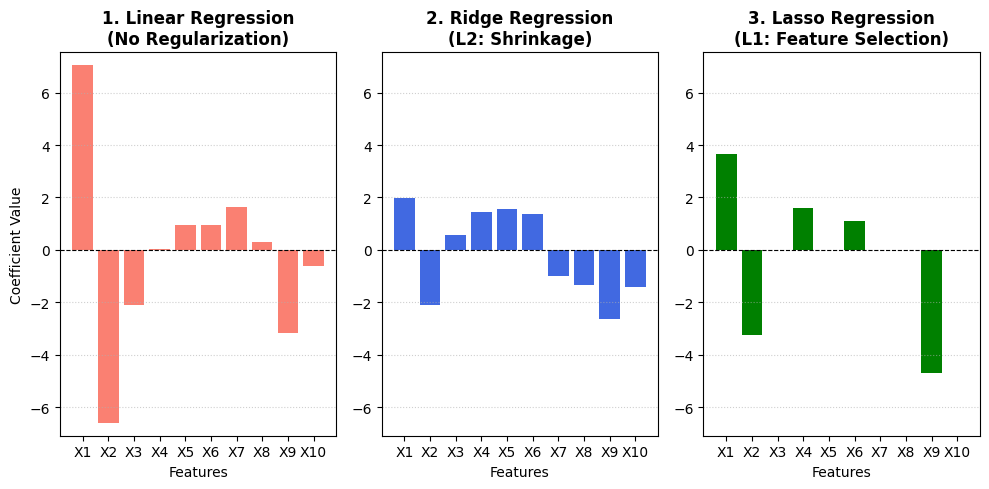

In [78]:
# 5. 시각화 (y축 스케일 통일)
plt.figure(figsize=(10, 5))
x_indices = np.arange(10)
feature_labels = [f'X{i}' for i in range(1, 11)]

# 첫 번째 그래프: 일반 선형 회귀
plt.subplot(1, 3, 1)
plt.bar(x_indices, lr.coef_, color='salmon')
plt.xticks(x_indices, feature_labels)
plt.ylim(y_min, y_max)  # y축 고정
plt.title("1. Linear Regression\n(No Regularization)", fontweight='bold')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.grid(axis='y', linestyle=':', alpha=0.6)

# 두 번째 그래프: Ridge 회귀
plt.subplot(1, 3, 2)
plt.bar(x_indices, ridge.coef_, color='royalblue')
plt.xticks(x_indices, feature_labels)
plt.ylim(y_min, y_max)  # y축 고정
plt.title("2. Ridge Regression\n(L2: Shrinkage)", fontweight='bold')
plt.xlabel('Features')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.grid(axis='y', linestyle=':', alpha=0.6)

# 세 번째 그래프: Lasso 회귀
plt.subplot(1, 3, 3)
plt.bar(x_indices, lasso.coef_, color='green')
plt.xticks(x_indices, feature_labels)
plt.ylim(y_min, y_max)  # y축 고정
plt.title("3. Lasso Regression\n(L1: Feature Selection)", fontweight='bold')
plt.xlabel('Features')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

1. Linear Regression (규제 없음): * $X_1$과 닮은 복제본들($X_3 \sim X_6$), 그리고 $X_2$와 닮은 복제본들($X_7 \sim X_{10}$)이 서로 가중치를 쪼개어 나누어 가졌다. 다중공선성 데이터에서 가중치가 잘게 쪼개지며 모델이 불안정해지는 전형적인 모습이다.
2. Ridge (L2 규제): * 가중치의 제곱합을 패널티로 주기 때문에, 어느 한 놈만 패지 않고 닮은 변수들을 다 같이 공평하게(Together) 0을 향해 하향 평준화시켰다. 모든 피처를 살려두되 기여도를 부드럽게 깎는 L2의 성향이 그대로 드러난다.
3. Lasso Regression ($L_1$ 규제): 유의미한 핵심 피처(X1, X2 계열)의 계수만 남기고, 대부분의 노이즈 피처(X3~X10) 계수를 작게 만든다. 불필요한 피처의 영향력을 완전히 제거하므로, 자체적으로 피처 선택(Feature Selection) 기능을 수행한다. (여기서는  X2  그룹 내에서  X2  본체 대신 노이즈인  X9 가 수학적 궤적과 우연한 잡음 덕분에 선택의 간택을 받아 가중치를 독식한 현상이 보임)